# Logistic Regression - Crime Prediction
This notebook trains a baseline Logistic Regression model on the Bangladesh Crime Dataset.

### 1. Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset using the exact path you provided
# The 'r' before the quote is important: it tells Python to read the Windows backslashes correctly!
df = pd.read_csv(r'C:\CrimeDataBD-1\data\raw\Bangladesh-Crime-Dataset.csv')
df.head()

,Unnamed: 0,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,latitude,longitude,incident_place,incident_district,...,literacy_rate,religious_institution,playground,park,police_station,cyber_cafe,school,college,cinema,crime
0,0,7,29,wednesday,0,morning,23.774569,90.355292,adabar,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
1,1,1,2,wednesday,0,night,23.774569,90.355292,adabar,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
2,2,1,4,tuesday,0,night,23.769808,90.351595,adabor,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
3,3,3,9,friday,1,night,23.728907,90.417137,aftabnagar,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
4,4,8,34,thursday,0,night,23.847177,90.404133,airport,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder


### 2. Data Cleaning & Preprocessing

In [2]:
# Drop the index-like column 
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

# Separate features (X) and target (y)
target_col = 'crime'
X = df.drop(target_col, axis=1)
y = df[target_col]

# Identify categorical columns and one-hot encode them
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Encode the target variable (crime types) to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_

### 3. Train/Test Split

In [3]:
# Stratified to handle class imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

### 4. Scale Numerical Features

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5. Train the Logistic Regression Model

In [5]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### 6. Evaluate the Model

In [6]:
y_pred = lr_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Model: Logistic Regression")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=classes))

Model: Logistic Regression
Accuracy: 0.3688
Macro F1-score: 0.3279

Classification Report:
               precision    recall  f1-score   support

     assault       0.37      0.30      0.33       219
   bodyfound       0.40      0.46      0.43       303
      kidnap       0.25      0.21      0.23       130
      murder       0.41      0.49      0.44       304
        rape       0.37      0.36      0.37       239
     robbery       0.23      0.14      0.17       120

    accuracy                           0.37      1315
   macro avg       0.34      0.33      0.33      1315
weighted avg       0.36      0.37      0.36      1315



### 7. Generate Confusion Matrix Plot

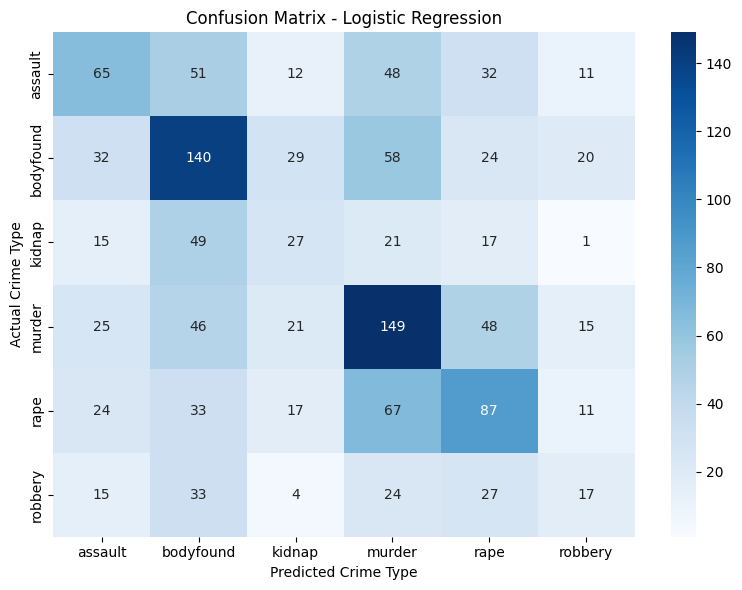

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Crime Type')
plt.ylabel('Actual Crime Type')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()